<a href="https://colab.research.google.com/github/sys8815701-creator/AI_26/blob/main/07_03_%EC%9D%B8%EA%B3%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D%EA%B8%B0%ED%83%80%EB%8F%84%EA%B5%AC(%EB%93%9C%EB%A1%AD%EC%95%84%EC%9B%83%2C%EC%BD%9C%EB%B0%B1%2C%EC%A1%B0%EA%B8%B0%EC%A2%85%EB%A3%8C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 인공 신경망을 구성하는 절차
# 1. 더미데이터를 준비한다.
# 2. 훈련용, 검증용, 테스트용으로 나눈다.
# 3. 심층(Dense)을 만든다.
# 4. model에 적용한다. (Sequential)
# 5. 컴파일을 진행한다. (최적화 기법을 적용한다. (adam))
# 6. fit (훈련)
# 7. evaluate (검증)
# 8. predict (예측)

In [ ]:
# 손실 곡선 : 'fit' 매서드로 모델을 훈련하는 동안, 훈련 과정이 상세하게 출력되어 확인할 수 있다. (에포크 횟수, 손실, 정확도)
# 코랩 노트북의 코드 셀은 'print' 명령어를 사용하지 않아도 마지막 라인에 실행 결과를 자동으로 출력한다.
# 다시 말해, 'fit' 매서드는 'History'라는 클래스 객체를 반환한다. (훈련 과정의 지표, 손실, 정확도 등을 내장한다.) → 이 값을 활용하면 그래프를 그릴 수 있다.

In [3]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) =\
     keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size = 0.2, random_state = 42
)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
print("훈련 데이터 : ")
print(train_scaled.shape, train_target.shape)
print("테스트 데이터 : ")
print(test_input.shape, test_target.shape)
print("검증 데이터 : ")
print(val_scaled.shape, val_target.shape)

훈련 데이터 : 
(48000, 28, 28) (48000,)
테스트 데이터 : 
(10000, 28, 28) (10000,)
검증 데이터 : 
(12000, 28, 28) (12000,)


In [5]:
# 모델을 만드는 함수를 정의한다. (하나의 매개변수를 받아서 리턴한다.) → .model_fn (dense를 추가하면 생성한다.)
def model_fn(a_layer=None) :
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28, 28))) # 반복적으로 사용되는 입력층
    model.add(keras.layers.Dense(100, activation='relu')) # 반복적으로 사용되는 이진 분류층

    # 'model_fn' 함수에'a_layer' 매개변수를 통해 케라스 층을 추가하면, 은닉층 뒤에 하나의 층을 추가한다.
    if a_layer :
      model.add(a_layer) # 메개 값으로 넘어오며 추가되는 층
    model.add(keras.layers.Dense(10, activation='softmax')) # 반복적으로 사용되는 다중 분류층
    return model

In [6]:
model = model_fn() # 앞서 만든 매서드를 호출하여 모델에 담는다. (매개 값이 없으면 생성하고, 있으면 추가한다.)
model.summary() # 모델의 요약된 정보를 출력한다.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#                             다중 분류                          정확도

In [8]:
# 'fit' 매서드의 결과를 'history' 변수에 담는다.
history = model.fit(train_scaled, train_target, epochs=5, verbose=2)
# verbose : 훈련 과정의 출력을 조절한다.
# verbose = 0 : 훈련 과정을 나타내지 않는다.
# verbose = 1 : 진행 막대와 함께 에포크마다 손실 등의 지표를 출력한다. (기본값)
# verbose = 2 : 진행 막대를 제외하고 출력한다.

Epoch 1/5
1500/1500 - 5s - 3ms/step - accuracy: 0.8112 - loss: 0.5311
Epoch 2/5
1500/1500 - 5s - 3ms/step - accuracy: 0.8586 - loss: 0.3903
Epoch 3/5
1500/1500 - 4s - 2ms/step - accuracy: 0.8729 - loss: 0.3523
Epoch 4/5
1500/1500 - 3s - 2ms/step - accuracy: 0.8810 - loss: 0.3306
Epoch 5/5
1500/1500 - 4s - 2ms/step - accuracy: 0.8873 - loss: 0.3141


In [9]:
print(history)

In [10]:
print(history.history.keys())

# 결과 : 훈련 측정 값이 담겨 있는 'history' 딕셔너리가 존재한다. (accuracy, loss) → 'compile' 매서드의 'metrics' 매개변수에 'accuracy'를 추가했기 때문에 'history' 속성에 포함되어 있다.

dict_keys(['accuracy', 'loss'])


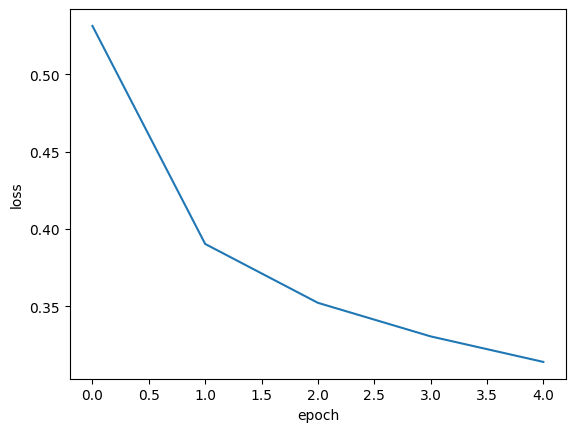

In [16]:
import matplotlib.pyplot as plt # 'history' 속성에 포함된 손실과 정확도는 에포크마다 계산한 값이기 때문에, 순서대로 나열된 단순한 리스트를 활용하여 맷플롯립 그래프 처리가 가능하다.

plt.plot(history.history['loss']) # 손실률을 차트로 표시한다.
plt.xlabel('epoch') # 파이썬 인덱스는 0부터 시작하기 때문에, 5개의 에포크가 0부터 4까지 x축에 표현된다.
plt.ylabel('loss') # 손실된 값
plt.show()

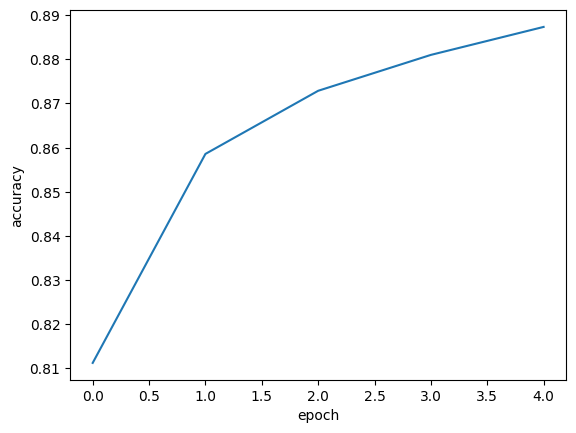

In [17]:
# 정확도를 출력한다.
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

# 결과 : 에포크마다 손실이 감소하고 정확도가 향상한다.

In [18]:
# 에포크 횟수를 20본까지 늘려보자.

model = model_fn() # 앞서 만든 매서드로 모델을 생성한다. (입력층, 은닉층, 출력층)
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0)

# 결과 : 약 1분 정도 걸린다.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


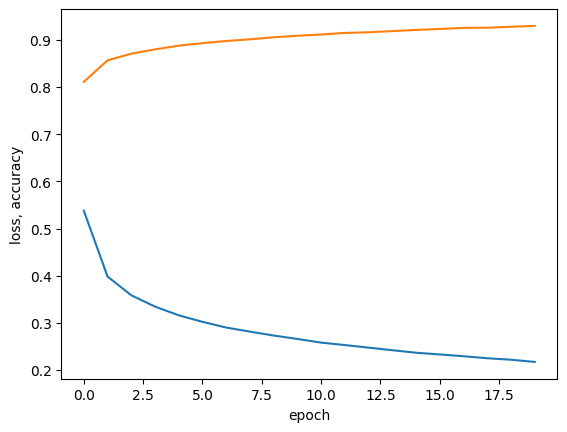

In [19]:
plt.plot(history.history['loss']) # 손실률
plt.plot(history.history['accuracy']) # 정확도
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.show()

In [ ]:
# 검증 손실 : validation_data=(val_scaled, val_target)

# 에포크에 따른 과대 적합, 과소 적합을 파악하기 위해, 훈련 세트 점수와 검증 세트 점수가 필요하다.
# 위와 같이 훈련 세트에 손실과 정확도만 그리면 파악하기 어렵기 때문에, 검증 손실을 활용하여 과대, 과소 적합을 응용한다.

# https://wikidocs.net/236194
# Q. 손실을 사용하는 것과 정확도를 사용하는 것의 차이는 무엇인가?
# A. 인공 신경망 모델이 최적화 하는 대상은 정확도가 아닌 손실 함수이다. 즉, 모델이 잘 훈련되었는지 판단하려면 정확도보다는 손실 함수의 값을 확인해야 한다.

In [20]:
model = model_fn()
model.summary()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target))

# 결과 : 검증 손실을 구하기 위한 매개 값이 추가되었다. (약 3분 정도 걸린다.)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7609 - loss: 0.6817 - val_accuracy: 0.8484 - val_loss: 0.4271
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8512 - loss: 0.4081 - val_accuracy: 0.8586 - val_loss: 0.3910
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8686 - loss: 0.3628 - val_accuracy: 0.8598 - val_loss: 0.3859
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8755 - loss: 0.3391 - val_accuracy: 0.8621 - val_loss: 0.3755
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8849 - loss: 0.3211 - val_accuracy: 0.8603 - val_loss: 0.3916
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8915 - loss: 0.3082 - val_accuracy: 0.8658 - val_loss: 0.3957
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8952 - loss: 0.2964 - val_accuracy: 0.8652 - val_loss: 0.3949
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8999 - loss: 0.2868 - 

In [21]:
print(history.history.keys())

# 결과 : 정확도와 손실과 더불어 검증 세트의 정확도(val_accuracy)와 손실(val_loss)이 출력되었다.

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


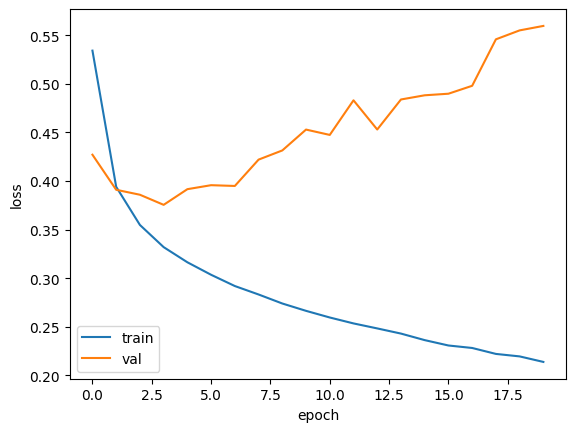

In [22]:
# 과대, 과소 적합 문제를 조사하기 위해 훈련 손실, 검증 손실을 실행한 그래프를 그려보자.
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# 결과 : 초기에 검증 손실이 감소하다가 다섯 번째 에포크만에 다시 상승한다.
# 훈련 손실은 꾸준히 감소하기 때문에, 과대 적합 모델이 만들어진다. → 검증 손실이 상승하는 시점을 가능한 늦추면 세트에 대한 손실이 줄어들고, 검증 세트에 대한 정확도가 증가할 것이다.

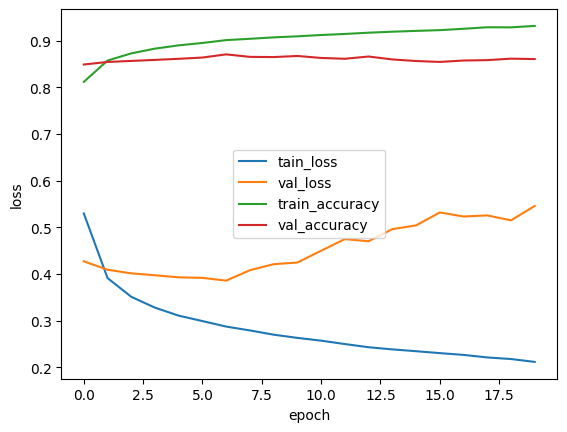

In [25]:
from sklearn.utils import validation
# 옵티마이저(최적화) 하이퍼 파라미터를 자동 조절하여 과대 적합을 완화시킨다.
model = model_fn()
model.compile(optimizer='RMSprop', loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['tain_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


TypeError: legend() takes 0-2 positional arguments but 4 were given

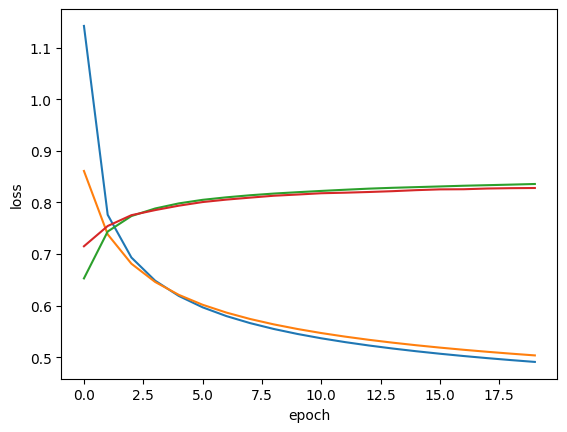

In [26]:
# Adagrad 기법으로 최척화를 한 후 차트로 확인해보자.
model = model_fn()
adagrad = keras.optimizers.Adagrad()
model.compile(optimizer=adagrad, loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend('train_loss', 'val_loss', 'train_accuracy', 'val_accuracy')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


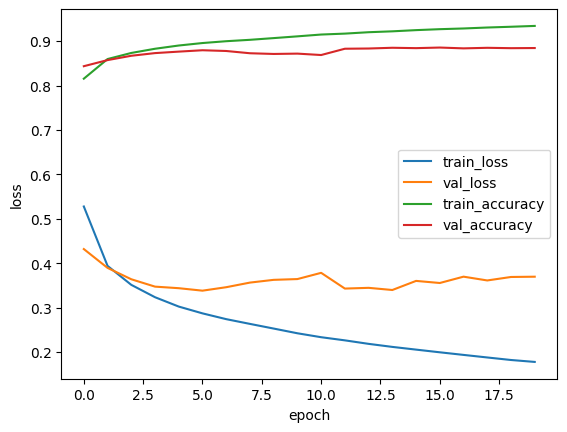

In [27]:
model = model_fn()

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])
plt.show()

# 결과 : 3가지의 최적화 기법을 사용해보니 'adam'이 가장 안정적으로 보인다.

In [ ]:
# 드롭아웃 (Drop Out) : 훈련 과정에서 층에 있는 일부 뉴런(더미데이터)을 무작위로 버린다. (뉴런 출력을 0으로 만든다.) → 과대 적합을 예방한다.
# 이유 : 이전 층의 일부 뉴런이 무작위로 버려진다면, 특정 뉴런에 과대하게 의존하기를 줄일 수 있다.

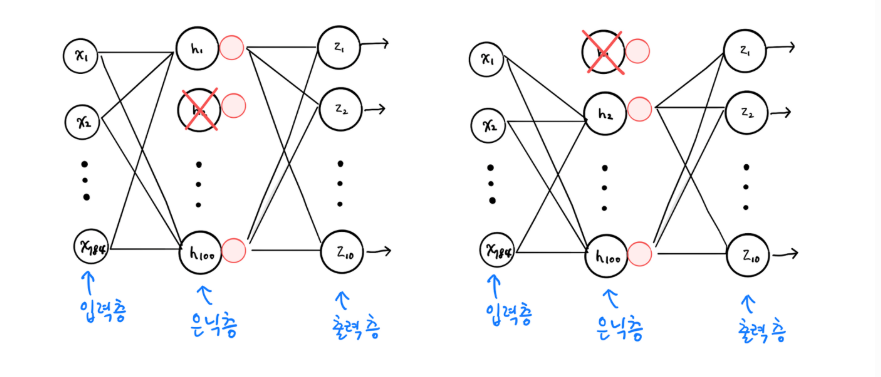

In [28]:
# 앙상블 : 더 좋은 예측을 만들기 위해, 여러 개의 모델을 훈련하는 머신러닝 알고리즘 → 과대 적합을 예방한다.

# 'model_fn' 함수에 드롭아웃 객체를 전달하여 층을 추가한다.
model = model_fn(keras.layers.Dropout(0.3)) # 약 30% 정도 드롭아웃 한다.

model.summary() # 요약을 확인한다.

# 결과
# 입력과 출력의 크기가 동일하다.
# 은닉층 뒤에 추가된 드롭아웃 층(3번째 값)은 훈련되는 모델 파라미터가 없다.
# 일부 뉴런의 출력을 0으로 만들지만, 전체 출력 배열의 크기를 바꾸지는 않는다.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

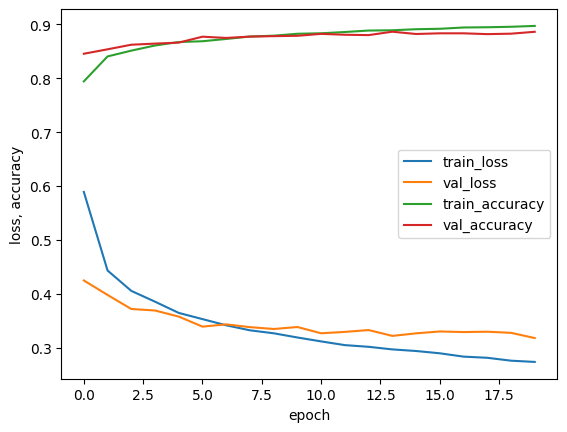

In [29]:
# 주의 사항
# 텐서플로와 케라스는 모델을 평가와 예측에 사용할 때 자동적으로 드롭아웃을 적용하지 않는다.
# 훈련된 모든 뉴런을 활용해야 올바른 예측이 수행되기 때문에, 훈련이 끝나고 평가나 예측을 수행할 때 드롭아웃을 적용하지 않는다.

# 훈련 손실과 검증 손실의 그래프를 그려보자.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])
plt.show()

# 결과
# 과대 적합이 확실하게 줄어들었다. (검증 손실의 감소가 멈추지만 크게 상승하지 않았다.)
# 20번의 에포크를 실행한 끝에 과대 적합이 되었다.

In [30]:
# 모델을 저장하고 복원해보자.
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_scaled, train_target, epochs=10, verbose=0,
                    validation_data=(val_scaled, val_target))

model.save('model-whole-ep10.keras') # 모델을 저장한다.

model.save_weights('model-ep10.weights.h5') # save_weights : 케라스 모델의 훈련된 모델 파라미터를 저장하는 매서드 → 'HDF5' 형식으로 저장된다. (폴더에서 확인한다.)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# model.save('model.keras') : 모델의 모든 정보를 저장한다. (e.g. '자동차 설계도 + 엔진 + 연료 상태'를 모두 저장한다.)
# 저장되는 정보 : 모델 구조 (Layer) | 학습된 가중치 | 옵티마이저 상태 | 컴파일 정보 (e.g. loss, metrics) → 완전히 동일한 모델을 바로 복원할 수 있다.

# model = load_model('model.keras') : 모델을 불러온다. → 코드 없이도 바로 복원할 수 있기 때문에, 배포 혹은 추론용으로 많이 사용된다.

# model.save_weights('model_weights.h5') : 가중치만 저장한다. (e.g. 엔진 정보만 저장한다.)
# 저장되는 정보 : 학습된 weights

# model = create_model() : 동일한 구조를 다시 생성한다.

# 주의 사항
# 데이터 → 학습 → 가중치
# 더미데이터는 저장하지 않는다. (대신 패턴인 가중치를 기억한다.)

In [ ]:
# 케라스 모델 (model.keras) 구조 : with zipfile.ZipFile("model.keras", 'r') as z :
#                                  print(z.namelist()) )
#                                  ['config.json', 'metadata.json', 'model.weights.h5']
#  └ config.json
#  └ metadata.json
#  └ model.weights.h5

# config.json 모델 구조 :
# {
#  "class_name": "Sequential",
#  "config": {
#    "layers": [
#      {
#        "class_name": "Dense",
#        "config": {
#          "units": 64,
#          "activation": "relu"
#        }
#      }
#    ]
#  }
# }

# 가중치 (model.weights.h5)
# dense/kernel : 0
# dense/bias : 0
# dense_1/kernel : 0
# dense_1/bias : 0
# 실제 값 : 가중치만 저장한다.
#  0.2312
# -0.7811
#  0.5321

# metadata.json
# {
#  "keras_version": "3.0",
#  "backend": "tensorflow"
# }

In [32]:
# 저장한 모델을 불러와서 테스트를 진행해보자.
!ls -al model*

-rw-r--r-- 1 root root 976600 Mar  5 03:28 model-ep10.weights.h5
-rw-r--r-- 1 root root 979409 Mar  5 03:28 model-whole-ep10.keras


In [33]:
# 실험 1 : 훈련하지 않은 새로운 모델을 생성하고, 'model-ep10.weights.h5' 파일에서 훈련된 모델 파라미터를 읽고 사용한다.

# 훈련하지 않은 새로운 모델을 생성한다.
model = model_fn(keras.layers.Dropout(0.3))

# 이전에 저장했던 모델 파라미터를 불러온다.
model.load_weights('model-ep10.weights.h5') # 'load_weight' 매서드는 'save_weight' 매서드와 쌍을 이룬다.
model.summary()

# 주의 사항 : 'load_weights' 매서드를 사용하려면, 'save_weight' 매서드로 저장했던 모델과 정확히 일치하는 구조를 가져야 한다.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# 모델의 검증 정확도를 확인해보자.
import numpy as np

val_labels = np.argmax(model.predict(val_scaled), axis=-1)
# argmax : 인덱스(val_labels)와 타깃(val_target)을 비교한 후, 위치의 값이 같으면 1, 다르면 0을 출력한다.
# predict : 사이킷런과 다른 샘플마다 10개의 클래스에 대한 확률을 반환한다. (다중 분류)
# axis=-1 : 배열의 마지막 차원을 따라 최대값을 고른다.

print(np.mean(val_labels == val_target)) # 평균으로 출력한다.

# 결과 : 약 88%

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
0.8815


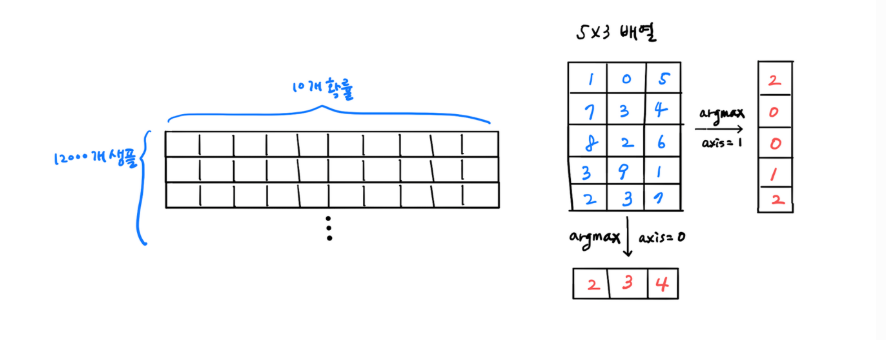

In [36]:
# 모델 전체를 파일에서 읽은 후, 검증 세트의 정확도를 출력한다.
model = keras.models.load_model('model-whole-ep10.keras')
model.evaluate(val_scaled, val_target) # 위와 동일한 모델이기 때문에 정확도가 일치한다.
# 케라스 모델을 저장하는 방법 : https://ltlkodae.tistory.com/13

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8848 - loss: 0.3264


[0.3283449411392212, 0.8815000057220459]

In [38]:
# 실험 2 : 파일에서 새로운 모델을 생성하고 바로 사용해보자. → 콜백

# 콜백 : 'keras.callbacks' 패기지에 있는 객체로서, 훈련 과정 중간에 특정 작업을 수행할 수 있게 돕는다.
# 'fit' 매서드의 'callback' 매개변수에 리스트로 전달하여 사용한다.
# 'save_best_only=True' 매개변수를 지정하여 가장 낮은 검증 점수를 만드는 모델을 저장할 수 있다.

model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras', # keras.callbacks.ModelCheckpoint : 콜백이 가장 낮은 검증 점수의 모델을 자동적으로 저장한다.
                                                save_best_only=True)
model.fit(train_scaled, train_target, epochs=20, verbose=1,
          validation_data=(val_scaled, val_target),
          callbacks=[checkpoint_cb])

# 결과 : 모델을 훈련한 후, 'best-model.keras'에 최상의 검증 점수를 도출한 모델이 저장된다.

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7348 - loss: 0.7720 - val_accuracy: 0.8445 - val_loss: 0.4312
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8342 - loss: 0.4560 - val_accuracy: 0.8622 - val_loss: 0.3816
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8509 - loss: 0.4147 - val_accuracy: 0.8633 - val_loss: 0.3664
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8564 - loss: 0.3866 - val_accuracy: 0.8683 - val_loss: 0.3544
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8647 - loss: 0.3712 - val_accuracy: 0.8720 - val_loss: 0.3549
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8696 - loss: 0.3576 - val_accuracy: 0.8710 - val_loss: 0.3512
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8708 - loss: 0.3424 - val_accuracy: 0.8793 - val_loss: 0.3371
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8741 - loss: 0.3347

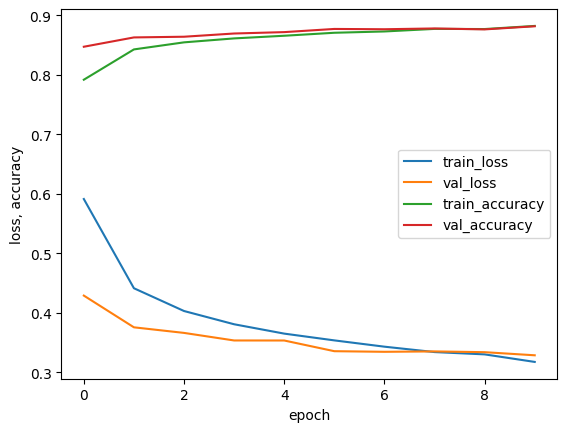

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8854 - loss: 0.3322


[0.33760035037994385, 0.8851666450500488]

In [39]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'])
plt.show()
model.evaluate(val_scaled, val_target)

# 결과 : 20번을 다 돌린 결과 좋은 점수가 도출된 9번째 에포크를 저장한다.

In [41]:
# EarlyStopping : 조기종료를 위한 콜백

model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.keras',
                                                save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)
# patience=2 : 연속 검증 점수가 향상되지 않으면 훈련을 중지한다.
# restore_best_weights=True : 가장 낮은 검증 손실을 도출한 모델 파라미터로 재정한다.

# 훈련을 중지한 후, 현재 모델의 파라미터를 최상의 파라미터로 재정한다.
history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7364 - loss: 0.7499 - val_accuracy: 0.8457 - val_loss: 0.4193
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8372 - loss: 0.4504 - val_accuracy: 0.8543 - val_loss: 0.3905
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8516 - loss: 0.4094 - val_accuracy: 0.8572 - val_loss: 0.3791
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8593 - loss: 0.3835 - val_accuracy: 0.8702 - val_loss: 0.3572
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8642 - loss: 0.3697 - val_accuracy: 0.8739 - val_loss: 0.3463
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8703 - loss: 0.3531 - val_accuracy: 0.8787 - val_loss: 0.3302
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.8742 - loss: 0.3430 - val_accuracy: 0.8715 - val_loss: 0.3471
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8764 - loss: 0.33

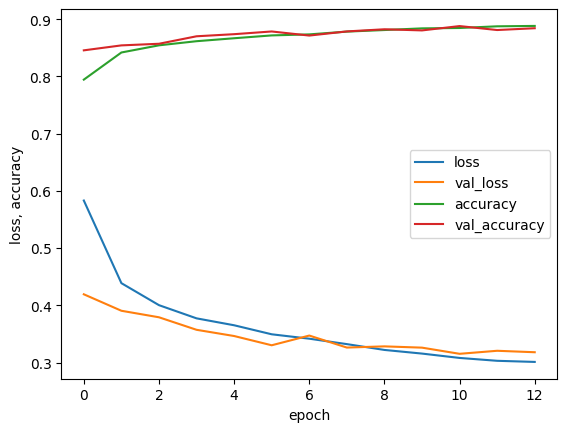

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8890 - loss: 0.3115


[0.31524282693862915, 0.8880833387374878]

In [43]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss, accuracy')
plt.legend(['loss', 'val_loss', 'accuracy', 'val_accuracy'])
plt.show()
model.evaluate(val_scaled, val_target)

# 결과 : 에포크를 10번 돌린 검증 세트의 성능이 출력되었다. (32.49%, 88.09%)